# Zepto Data & AI Capstone: Analytics Module
This notebook profiles the scraped dataset and builds predictive models, acting as the analytics pipeline.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading
We load the `books` and `categories` tables from the SQLite database.

In [2]:
conn = sqlite3.connect('../zepto.db')
books_df = pd.read_sql("SELECT * FROM books", conn)
cats_df = pd.read_sql("SELECT * FROM categories", conn)
df = pd.merge(books_df, cats_df, on='category_id')
conn.close()

df.head()

,book_id,title,price_gbp,price_inr,rating,in_stock,category_id,category_name
0,1,Sharp Objects,47.82,5045.010,4,1,1,Mystery
1,2,"In a Dark, Dark Wood",19.63,2070.965,1,1,1,Mystery
2,3,The Past Never Ends,56.50,5960.750,4,1,1,Mystery
3,4,A Murder in Time,16.64,1755.520,1,1,1,Mystery
4,5,The Murder of Roger Ackroyd (Hercule Poirot #4),44.10,4652.550,4,1,1,Mystery


## 2. Exploratory Data Analysis (EDA)
Let's visualize the distribution of prices and the impact of ratings.

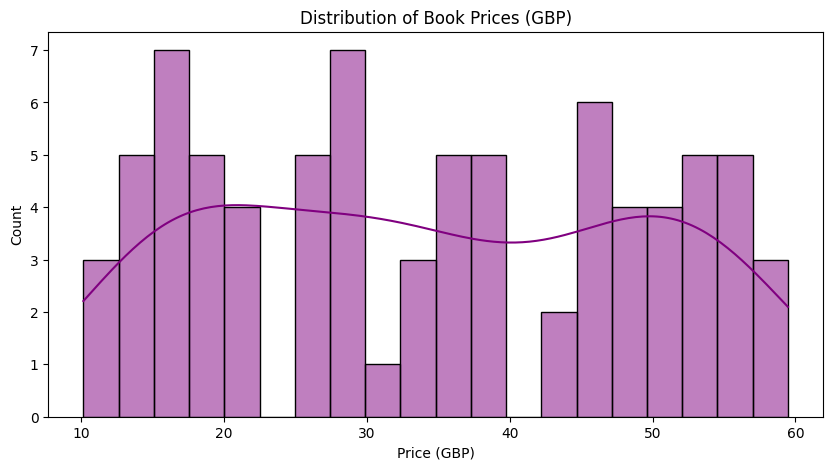

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price_gbp'], bins=20, kde=True, color='purple')
plt.title('Distribution of Book Prices (GBP)')
plt.xlabel('Price (GBP)')
plt.ylabel('Count')
plt.show()

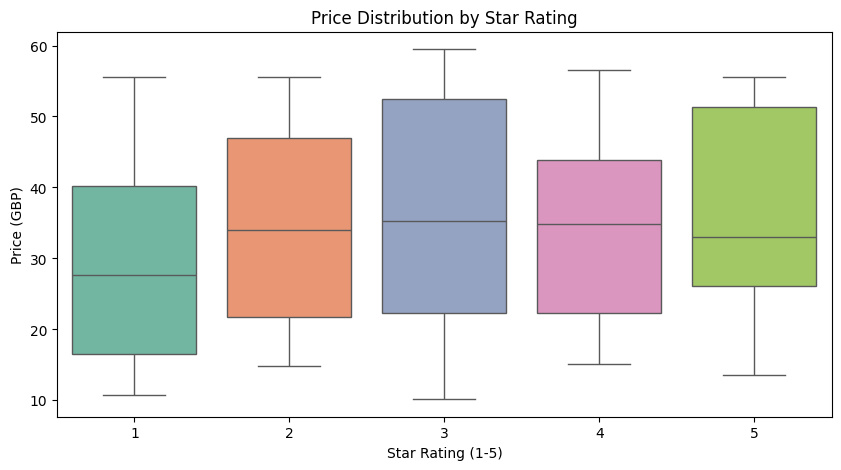

In [4]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='rating', y='price_gbp', data=df, palette='Set2')
plt.title('Price Distribution by Star Rating')
plt.xlabel('Star Rating (1-5)')
plt.ylabel('Price (GBP)')
plt.show()

## 3. Predictive Modeling
We will train a model to predict the **price** of a book based on its rating and category.
First, we encode the categorical variables.

In [5]:
# Encode category
df_encoded = pd.get_dummies(df, columns=['category_name'], drop_first=True)

X = df_encoded.drop(columns=['book_id', 'title', 'price_gbp', 'price_inr', 'category_id'])
y = df_encoded['price_gbp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Baseline Model: Linear Regression

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
preds = lr.predict(X_test)
print(f"Linear Regression MAE: £{mean_absolute_error(y_test, preds):.2f}")

Linear Regression MAE: £13.37


### Advanced Model: Random Forest with GridSearchCV

In [7]:
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
rf_preds = best_rf.predict(X_test)

print(f"Best RF Params: {grid.best_params_}")
print(f"Random Forest MAE: £{mean_absolute_error(y_test, rf_preds):.2f}")

Best RF Params: {'max_depth': 5, 'n_estimators': 100}
Random Forest MAE: £11.15


### Feature Importances

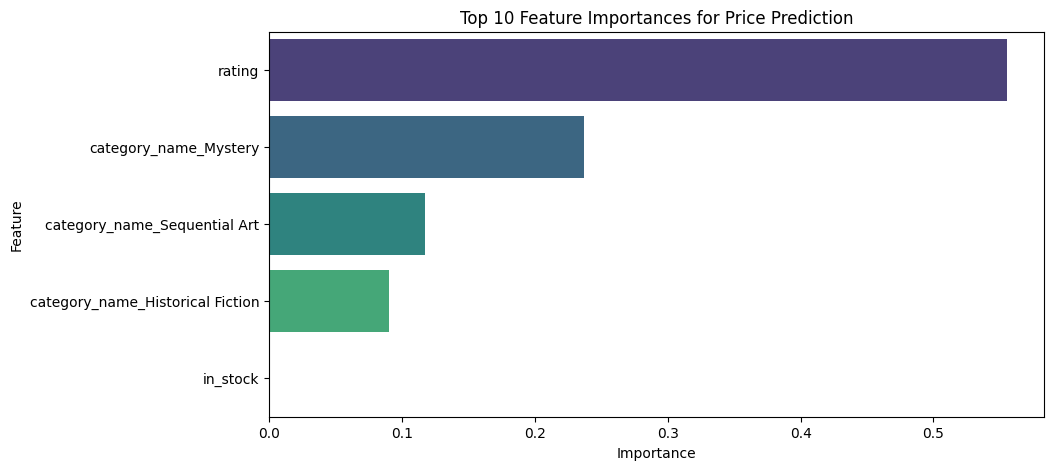

In [8]:
importances = best_rf.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances for Price Prediction')
plt.show()